In [ ]:
import os
import sys
import onnx
import time
import torch
import numpy as np
import onnxruntime
import polars as pl
import matplotlib.pyplot as plt
from IPython.display import display

# Add project root to path
project_root = os.path.abspath('..') 
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from networks.PeakDetectionModel import PeakDetectionModel
from torch.utils.data import DataLoader
from dataloader.SignalDataset import SignalDataset

# -------------------- HARD-CODED PARAMETERS --------------------
data_dir = os.path.join(project_root, "data")
signal_path = os.path.join(data_dir, "signal.raw")
info_path = os.path.join(data_dir, "info.raw")
test_indices = os.path.join(data_dir, "test_indices.pt")

chunks = 1024
max_peaks = 3
batch_size = 32
shuffle = True
train_split = 0.75
val_split = 0.15
seed = 42  

threshold = 0.009

# -------------------- CONFIGURATION --------------------
model_path = "../networks/final_model.pt"
onnx_path = "../networks/peak_detection_model.onnx"
device = "cuda" if torch.cuda.is_available() else "cpu"

# Create a config object with all needed attributes
class Config:
    signal_path = signal_path
    info_path = info_path
    chunks = chunks
    max_peaks = max_peaks
    batch_size = batch_size
    shuffle = shuffle
    train_split = train_split
    val_split = val_split
    seed = seed 
    device = device

args = Config()
print(f"\nRunning inference on device: {device}")
print(f"Loading model from: {model_path}")


print(onnxruntime.get_available_providers())


Running inference on device: cuda
Loading model from: ../networks/final_model.pt
['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']


In [57]:
# -------------------- DATASET --------------------
indices = torch.load(test_indices)

dataset = SignalDataset(
    signal_path=os.path.join("..", "data", "signal.raw"),
    info_path=os.path.join("..", "data", "info.raw"),
    chunks=1024,
    max_peaks=3
)

test_dataset = torch.utils.data.Subset(dataset, indices)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Test samples: {len(test_dataset)}")
print(f"Batch size: {test_loader.batch_size}")
print(f"Num batches: {len(test_loader)}")

Test samples: 5000
Batch size: 32
Num batches: 157


In [58]:
# -------------------- MODEL --------------------
model = PeakDetectionModel(signal_length=chunks, max_peaks=max_peaks)
print(model.encoder[0].name)                # "entry_layer"
print(model.fc_positions.name)              # "final_layer_positions"
print(model.fc_heights.name)                # "final_layer_heights"
print(model.fc_widths.name)                 # "final_layer_widths"

model.load_state_dict(torch.load(model_path, map_location=device))
model.to(device)
model.eval()

entry_layer
final_layer_positions
final_layer_heights
final_layer_widths


PeakDetectionModel(
  (encoder): Sequential(
    (0): Conv1d(1, 32, kernel_size=(13,), stride=(1,))
    (1): ReLU()
    (2): Conv1d(32, 64, kernel_size=(13,), stride=(1,))
    (3): ReLU()
    (4): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=True)
  )
  (fc): Sequential(
    (0): Linear(in_features=32000, out_features=2048, bias=True)
    (1): ReLU()
  )
  (fc_positions): Linear(in_features=2048, out_features=1024, bias=True)
  (fc_heights): Linear(in_features=2048, out_features=3, bias=True)
  (fc_widths): Linear(in_features=2048, out_features=3, bias=True)
)

# ONNX

https://docs.pytorch.org/tutorials/beginner/onnx/export_simple_model_to_onnx_tutorial.html

In [59]:
onnx_model = onnx.load(onnx_path)
onnx.checker.check_model(onnx_model)
print("ONNX model is valid ✅")

example_inputs = (torch.randn(1, 1, model.signal_length),)
onnx_inputs = [tensor.numpy(force=True) for tensor in example_inputs]
print(f"Input length: {len(onnx_inputs)}")
print(f"Sample input: {onnx_inputs}")

ort_session = onnxruntime.InferenceSession(
   # onnx_path, providers=["CPUExecutionProvider"]
    onnx_path, providers=["CUDAExecutionProvider"]
)

onnxruntime_input = {input_arg.name: input_value for input_arg, input_value in zip(ort_session.get_inputs(), onnx_inputs)}

# ONNX Runtime returns a list of outputs
onnxruntime_outputs = ort_session.run(None, onnxruntime_input)[0]

ONNX model is valid ✅
Input length: 1
Sample input: [array([[[-1.9615679 , -0.79431695,  1.1863056 , ...,  0.13530152,
         -0.06019822,  0.83623177]]], shape=(1, 1, 1024), dtype=float32)]


# Comparison ONNX - Pytorch

In [60]:
model.eval()
model.cpu()
torch_outputs = model(*example_inputs)
print(type(torch_outputs))     
print(len(torch_outputs))      
for i, t in enumerate(torch_outputs):
    print(f"output {i}: shape={t.shape}, dtype={t.dtype}")

print(len(onnxruntime_outputs))
for i, o in enumerate(onnxruntime_outputs):
    print(f"onnx output {i}: shape={o.shape}, dtype={o.dtype}")

<class 'tuple'>
3
output 0: shape=torch.Size([1, 1024]), dtype=torch.float32
output 1: shape=torch.Size([1, 3]), dtype=torch.float32
output 2: shape=torch.Size([1, 3]), dtype=torch.float32
1
onnx output 0: shape=(1024,), dtype=float32


In [61]:
# ============================================================
# ONNX vs PyTorch
# ============================================================

# 1. PyTorch inference
model.eval()
model.cpu()
torch_outputs = model(*example_inputs)

# 2. ONNX inference
ort_session = onnxruntime.InferenceSession(onnx_path, providers=["CUDAExecutionProvider"])
output_names = [o.name for o in ort_session.get_outputs()]
print("Fetching outputs:", output_names)  # ['sigmoid', 'relu_3', 'relu_4']

ort_inputs = {ort_session.get_inputs()[0].name: example_inputs[0].numpy()}
onnxruntime_outputs = ort_session.run(output_names, ort_inputs) 

print(f"PyTorch outputs: {len(torch_outputs)}")
print(f"ONNX outputs:    {len(onnxruntime_outputs)}")

# 3. Comparison
assert len(torch_outputs) == len(onnxruntime_outputs), \
    f"Mismatch: PyTorch={len(torch_outputs)}, ONNX={len(onnxruntime_outputs)}"

for i, (torch_out, onnx_out) in enumerate(zip(torch_outputs, onnxruntime_outputs)):
    torch.testing.assert_close(
        torch_out,
        torch.tensor(onnx_out),
        rtol=1e-3,
        atol=1e-5
    )
    print(f"Output {i} ({output_names[i]}): ✅ match  shape={torch_out.shape}")

print("✅ PyTorch and ONNX Runtime output matched!")

Fetching outputs: ['positions', 'heights', 'widths']
PyTorch outputs: 3
ONNX outputs:    3
Output 0 (positions): ✅ match  shape=torch.Size([1, 1024])
Output 1 (heights): ✅ match  shape=torch.Size([1, 3])
Output 2 (widths): ✅ match  shape=torch.Size([1, 3])
✅ PyTorch and ONNX Runtime output matched!


# Compare Inferences

# ONNX inference

In [62]:
signals, true_pos, true_heights, true_widths = next(iter(test_loader))
signal = signals[0:1]

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
signal = signal.to(device)

ort_session = onnxruntime.InferenceSession(
    onnx_path,
    providers=["CUDAExecutionProvider", "CPUExecutionProvider"]
)

ort_inputs = {ort_session.get_inputs()[0].name: signals[0:1].unsqueeze(1).numpy()}  # (1, 1, 1024)
output_names = [o.name for o in ort_session.get_outputs()]
onnxruntime_outputs = ort_session.run(output_names, ort_inputs) 
onnx_positions = onnxruntime_outputs[0]
onnx_heights = onnxruntime_outputs[0]
onnx_widths = onnxruntime_outputs[0]

onnx_positions = onnxruntime_outputs[0].flatten()
onnx_heights   = onnxruntime_outputs[1].flatten()
onnx_widths    = onnxruntime_outputs[2].flatten()

# PyTorch inference

In [63]:
signals, true_pos, true_heights, true_widths = next(iter(test_loader))
signal = signals[0].cpu().numpy().squeeze() 
gt_pos = true_pos[0].numpy()

# --- PyTorch inference ---
device = "cuda" if torch.cuda.is_available() else "cpu"

model = model.to(device)

signal_torch = signals[0:1].to(device)  # (1, 1, 1024)
# save it
output_path = os.path.join(data_dir, "test_signal.raw")
signal.astype(np.float32).tofile(output_path)
print("Signal shape:", signal.shape)
print("Saved to:", output_path)

model.eval()
with torch.no_grad():
    pt_positions, pt_heights, pt_widths = model(signal_torch.unsqueeze(1))
pt_positions = pt_positions[0].cpu().numpy()
pt_heights   = pt_heights[0].cpu().numpy()
pt_widths    = pt_widths[0].cpu().numpy()

Signal shape: (1024,)
Saved to: c:\Users\fabio\Documents\GitHub\1DSignalProcessing\data\test_signal.raw


### Debug

In [74]:
threshold = 1e-4
values = np.array(pt_positions).flatten()
df = pl.DataFrame({
    "index": np.arange(len(values)),
    "value": np.where(np.abs(values) < threshold, 0.0, values)
})

print(df)

shape: (1_024, 2)
┌───────┬───────┐
│ index ┆ value │
│ ---   ┆ ---   │
│ i64   ┆ f32   │
╞═══════╪═══════╡
│ 0     ┆ 0.0   │
│ 1     ┆ 0.0   │
│ 2     ┆ 0.0   │
│ 3     ┆ 0.0   │
│ 4     ┆ 0.0   │
│ …     ┆ …     │
│ 1019  ┆ 0.0   │
│ 1020  ┆ 0.0   │
│ 1021  ┆ 0.0   │
│ 1022  ┆ 0.0   │
│ 1023  ┆ 0.0   │
└───────┴───────┘


In [65]:
for v in np.array(pt_heights).flatten():
    print(v)


87.641624
0.0
0.0


In [66]:
for v in np.array(pt_widths).flatten():
    print(v)


0.0
0.0
0.0


In [67]:
print(onnx_positions.shape, pt_positions.shape)
print(signals[0].cpu().numpy().squeeze().shape)
print(signals[0:1].unsqueeze(1).numpy().shape)

(1024,) (1024,)
(1024,)
(1, 1, 1024)


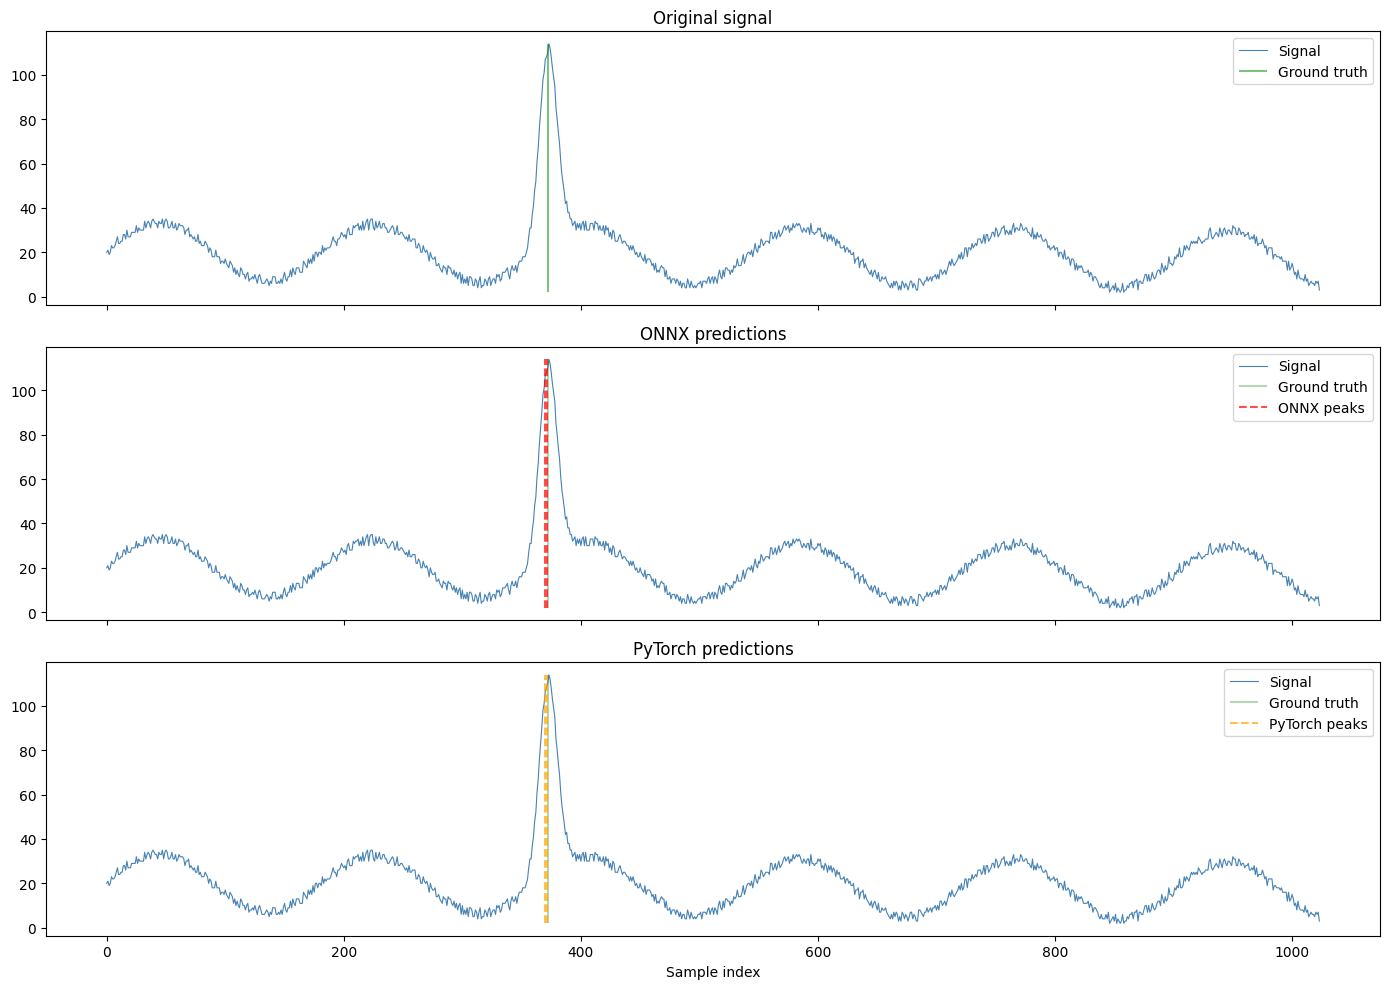

In [68]:
def get_top_peaks(positions, threshold=0.0, n=3):
    positions = np.array(positions).flatten()
    indices = np.where(positions > threshold)[0].tolist()
    return sorted(indices, key=lambda i: float(positions[i]), reverse=True)[:n]

threshold = 0.005
onnx_peaks = get_top_peaks(onnx_positions, threshold)
pt_peaks   = get_top_peaks(pt_positions, threshold)
gt_indices = np.where(gt_pos > threshold)[0]

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(signal, color="steelblue", linewidth=0.8, label="Signal")
axes[0].vlines(gt_indices, ymin=signal.min(), ymax=signal.max(),
               colors="green", linestyles="-", alpha=0.5, label="Ground truth")
axes[0].set_title("Original signal")
axes[0].legend()

axes[1].plot(signal, color="steelblue", linewidth=0.8, label="Signal")
axes[1].vlines(gt_indices, ymin=signal.min(), ymax=signal.max(),
               colors="green", linestyles="-", alpha=0.3, label="Ground truth")
axes[1].vlines(onnx_peaks, ymin=signal.min(), ymax=signal.max(),
               colors="red", linestyles="--", alpha=0.7, label="ONNX peaks")
axes[1].set_title("ONNX predictions")
axes[1].legend()

axes[2].plot(signal, color="steelblue", linewidth=0.8, label="Signal")
axes[2].vlines(gt_indices, ymin=signal.min(), ymax=signal.max(),
               colors="green", linestyles="-", alpha=0.3, label="Ground truth")
axes[2].vlines(pt_peaks, ymin=signal.min(), ymax=signal.max(),
               colors="orange", linestyles="--", alpha=0.7, label="PyTorch peaks")
axes[2].set_title("PyTorch predictions")
axes[2].set_xlabel("Sample index")
axes[2].legend()

plt.tight_layout()
plt.show()

In [69]:
n_onnx = len(onnx_peaks)
n_pt   = len(pt_peaks)

df = pl.DataFrame({
    "Model":    ["ONNX"] * n_onnx + ["PyTorch"] * n_pt,
    "Peak":     list(range(n_onnx)) + list(range(n_pt)),
    "Position": onnx_peaks + pt_peaks,
    "Height":   onnx_heights[:n_onnx].tolist() + pt_heights[:n_pt].tolist(),
    "Width":    onnx_widths[:n_onnx].tolist()  + pt_widths[:n_pt].tolist(),
})

display(df)

Model,Peak,Position,Height,Width
str,i64,i64,f64,f64
"""ONNX""",0,370,87.641624,0.0
"""ONNX""",1,371,0.0,0.0
"""PyTorch""",0,370,87.641624,0.0
"""PyTorch""",1,371,0.0,0.0


# Inference Speed

### ONNX

In [70]:
# Warm-up
for _ in range(20):
    ort_session.run(["positions", "heights", "widths"], ort_inputs)

# Benchmark
N = 2000
start = time.perf_counter()
for _ in range(N):
    ort_session.run(["positions", "heights", "widths"], ort_inputs)
elapsed = time.perf_counter() - start

print(f"Mean latency: {elapsed/N*1000:.2f} ms")
print(f"Throughput:   {N/elapsed:.1f} qps")

Mean latency: 2.83 ms
Throughput:   353.4 qps


### Python

In [71]:
for _ in range(20):  # warm-up
    model(signal_torch.unsqueeze(1))
torch.cuda.synchronize()

N = 2000
start = time.perf_counter()
for _ in range(N):
    model(signal_torch.unsqueeze(1))

# important! otherwise mesuring how fast cpu comands gpu
torch.cuda.synchronize() 

elapsed = time.perf_counter() - start

print(f"Mean latency: {elapsed/N*1000:.2f} ms")

Mean latency: 2.51 ms


### TensorRT